In [7]:
import os
import re
import random
import numpy as np
import pandas as pd
import torch
import librosa

from datasets import Dataset
from transformers import (
    Wav2Vec2Processor,
    Wav2Vec2ForCTC,
    TrainingArguments,
    Trainer
)

import evaluate

c:\Users\Madesh\Desktop\Data Science Project\Noisy_Speech_Recognition\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

In [9]:
print("CUDA available:", torch.cuda.is_available())

device = "cuda" if torch.cuda.is_available() else "cpu"

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: NVIDIA GeForce RTX 3050


In [10]:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

CLEAN_MODEL_PATH = os.path.join(PROJECT_ROOT, "models", "clean", "final_model")
NOISY_MODEL_PATH = os.path.join(PROJECT_ROOT, "models", "noisy", "final_model")

BASE_PATH = "../data/clean/LibriSpeech/train-clean-100"
NOISE_PATH = "../data/musan/noise"

In [11]:
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base-960h")

In [12]:
clean_model = Wav2Vec2ForCTC.from_pretrained(CLEAN_MODEL_PATH).to(device)
noisy_model = Wav2Vec2ForCTC.from_pretrained(NOISY_MODEL_PATH).to(device)

clean_model.eval()
noisy_model.eval()

Loading weights: 100%|██████████| 213/213 [00:00<00:00, 418.38it/s, Materializing param=wav2vec2.masked_spec_embed]                                            


Wav2Vec2ForCTC(
  (wav2vec2): Wav2Vec2Model(
    (feature_extractor): Wav2Vec2FeatureEncoder(
      (conv_layers): ModuleList(
        (0): Wav2Vec2GroupNormConvLayer(
          (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
          (activation): GELUActivation()
          (layer_norm): GroupNorm(512, 512, eps=1e-05, affine=True)
        )
        (1-4): 4 x Wav2Vec2NoLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
          (activation): GELUActivation()
        )
        (5-6): 2 x Wav2Vec2NoLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
          (activation): GELUActivation()
        )
      )
    )
    (feature_projection): Wav2Vec2FeatureProjection(
      (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (projection): Linear(in_features=512, out_features=768, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder)

In [13]:
data = []

for root, dirs, files in os.walk(BASE_PATH):
    for file in files:
        if file.endswith(".trans.txt"):
            trans_path = os.path.join(root, file)
            with open(trans_path, "r") as f:
                lines = f.readlines()

            for line in lines:
                parts = line.strip().split(" ", 1)
                file_id = parts[0]
                text = parts[1].lower()
                audio_path = os.path.join(root, file_id + ".flac")

                if os.path.exists(audio_path):
                    data.append({
                        "audio_path": audio_path,
                        "text": text
                    })

df = pd.DataFrame(data)

In [14]:
def normalize_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z ']", "", text)
    return text

df["clean_text"] = df["text"].apply(normalize_text)

df_train = df.sample(5000, random_state=42).reset_index(drop=True)

In [15]:
TARGET_SR = 16000

def load_audio(path):
    y, sr = librosa.load(path, sr=None)
    if sr != TARGET_SR:
        y = librosa.resample(y, orig_sr=sr, target_sr=TARGET_SR)
    return y.astype("float32")

noise_files = []
for root, dirs, files in os.walk(NOISE_PATH):
    for file in files:
        if file.endswith(".wav"):
            noise_files.append(os.path.join(root, file))

def add_noise(clean, noise, snr_db):
    if len(noise) < len(clean):
        repeat = int(np.ceil(len(clean) / len(noise)))
        noise = np.tile(noise, repeat)

    noise = noise[:len(clean)]

    clean_power = np.mean(clean ** 2)
    noise_power = np.mean(noise ** 2)
    snr = 10 ** (snr_db / 10)

    scale = np.sqrt(clean_power / (snr * noise_power))
    noisy = clean + scale * noise

    return noisy

In [16]:
TRAIN_MODE = "clean"

def prepare_dataset(example):
    audio = load_audio(example["audio_path"])

    if TRAIN_MODE == "noisy":
        noise_audio = load_audio(random.choice(noise_files))
        snr_db = np.random.uniform(0, 20)
        audio = add_noise(audio, noise_audio, snr_db)

    inputs = processor(audio, sampling_rate=16000)
    labels = processor(text=example["clean_text"].upper()).input_ids

    example["input_values"] = inputs.input_values[0]
    example["labels"] = labels

    return example

In [17]:
# CLEAN EVAL
TRAIN_MODE = "clean"

clean_dataset = Dataset.from_pandas(df_train)
clean_dataset = clean_dataset.map(
    prepare_dataset,
    remove_columns=clean_dataset.column_names
)
clean_dataset = clean_dataset.train_test_split(test_size=0.1)
clean_eval = clean_dataset["test"]

# NOISY EVAL
TRAIN_MODE = "noisy"

noisy_dataset = Dataset.from_pandas(df_train)
noisy_dataset = noisy_dataset.map(
    prepare_dataset,
    remove_columns=noisy_dataset.column_names
)
noisy_dataset = noisy_dataset.train_test_split(test_size=0.1)
noisy_eval = noisy_dataset["test"]

Map: 100%|██████████| 5000/5000 [01:58<00:00, 42.09 examples/s]


In [18]:
class DataCollatorCTCWithPadding:
    def __init__(self, processor, padding=True):
        self.processor = processor
        self.padding = padding

    def __call__(self, features):
        input_features = [{"input_values": f["input_values"]} for f in features]
        label_features = [{"input_ids": f["labels"]} for f in features]

        batch = self.processor.pad(
            input_features,
            padding=self.padding,
            return_tensors="pt",
        )

        labels_batch = self.processor.tokenizer.pad(
            label_features,
            padding=self.padding,
            return_tensors="pt",
        )

        labels = labels_batch["input_ids"]
        labels[labels == self.processor.tokenizer.pad_token_id] = -100
        batch["labels"] = labels

        return batch

data_collator = DataCollatorCTCWithPadding(processor=processor)

In [19]:
wer_metric = evaluate.load("wer")
cer_metric = evaluate.load("cer")

def compute_metrics(pred):
    pred_ids = np.argmax(pred.predictions, axis=-1)
    pred_str = processor.batch_decode(pred_ids, group_tokens=True)

    label_ids = pred.label_ids
    label_ids[label_ids == -100] = processor.tokenizer.pad_token_id
    label_str = processor.batch_decode(label_ids, group_tokens=False)

    wer = wer_metric.compute(predictions=pred_str, references=label_str)
    cer = cer_metric.compute(predictions=pred_str, references=label_str)

    return {"wer": wer, "cer": cer}

In [20]:
eval_args = TrainingArguments(
    output_dir="./temp_eval",
    per_device_eval_batch_size=4,
    eval_strategy="no",
    logging_strategy="no",
    report_to="none"
)

clean_trainer = Trainer(
    model=clean_model,
    args=eval_args,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

noisy_trainer = Trainer(
    model=noisy_model,
    args=eval_args,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

In [21]:
print("Clean model on CLEAN eval:")
cc = clean_trainer.evaluate(clean_eval)

print("Clean model on NOISY eval:")
cn = clean_trainer.evaluate(noisy_eval)

print("Noisy model on CLEAN eval:")
nc = noisy_trainer.evaluate(clean_eval)

print("Noisy model on NOISY eval:")
nn = noisy_trainer.evaluate(noisy_eval)

print("\nFINAL WER RESULTS")
print("Clean → Clean:", cc["eval_wer"])
print("Clean → Noisy:", cn["eval_wer"])
print("Noisy → Clean:", nc["eval_wer"])
print("Noisy → Noisy:", nn["eval_wer"])

Clean model on CLEAN eval:


Clean model on NOISY eval:
Noisy model on CLEAN eval:


Noisy model on NOISY eval:

FINAL WER RESULTS
Clean → Clean: 0.01096922990380829
Clean → Noisy: 0.10010129297503426
Noisy → Clean: 0.015300669404286437
Noisy → Noisy: 0.03712089614490854


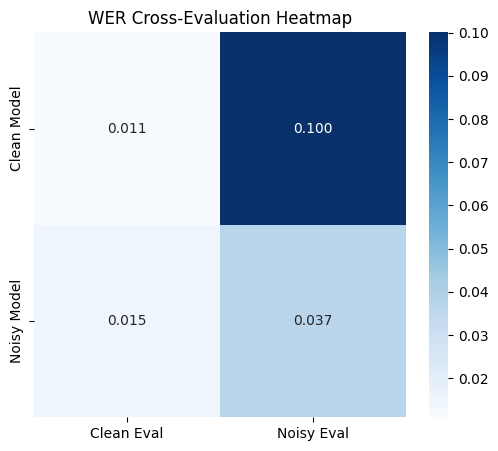

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

wer_matrix = np.array([
    [cc["eval_wer"], cn["eval_wer"]],
    [nc["eval_wer"], nn["eval_wer"]]
])

plt.figure(figsize=(6,5))
sns.heatmap(wer_matrix, 
            annot=True, 
            fmt=".3f",
            xticklabels=["Clean Eval", "Noisy Eval"],
            yticklabels=["Clean Model", "Noisy Model"],
            cmap="Blues")

plt.title("WER Cross-Evaluation Heatmap")
plt.show()

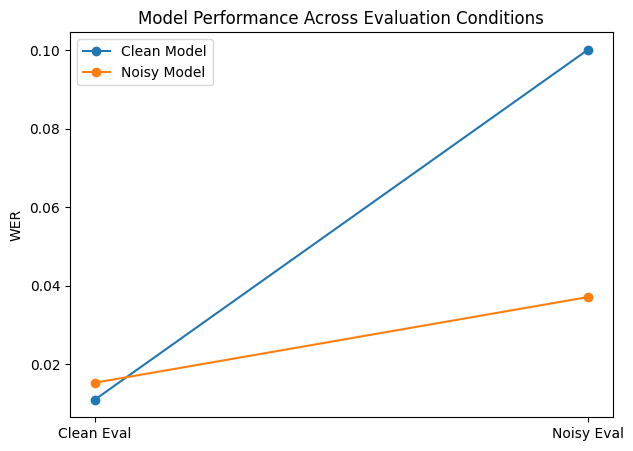

In [28]:
models = ["Clean Model", "Noisy Model"]

clean_scores = [cc["eval_wer"], cn["eval_wer"]]
noisy_scores = [nc["eval_wer"], nn["eval_wer"]]

plt.figure(figsize=(7,5))
plt.plot(["Clean Eval", "Noisy Eval"], clean_scores, marker="o", label="Clean Model")
plt.plot(["Clean Eval", "Noisy Eval"], noisy_scores, marker="o", label="Noisy Model")

plt.ylabel("WER")
plt.title("Model Performance Across Evaluation Conditions")
plt.legend()
plt.show()

In [31]:
improvement = (cn["eval_wer"] - nn["eval_wer"]) / cn["eval_wer"] * 100
print(f"Noise training reduces WER under noisy condition by {improvement:.2f}%")

Noise training reduces WER under noisy condition by 62.92%


## Evaluation Summary

The clean-trained model achieves excellent performance on clean data (WER ≈ 1.1%) 
but degrades significantly under noisy conditions (≈ 10%).

The noise-trained model maintains strong performance on both clean (≈ 1.5%) 
and noisy (≈ 3.7%) data.

This demonstrates that noise augmentation significantly improves robustness 
without severely compromising clean performance.